In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:


import torch
import numpy as np
import matplotlib.pyplot as plt

import src.trainer.schrodinger_train as wave_train

from src.utils.logger          import Logging
from src.utils.plot_loss       import smooth_loss
from src.utils.plot_prediction import plt_prediction

from src.nn.DVPDESolver        import DVPDESolver
from src.nn.CVPDESolver        import CVPDESolver
from src.nn.ClassicalSolver2   import ClassicalSolver2
from data.synthetic.schrodinger_dataset import exact_eigenstate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# ---- Selección de potencial y solver ----
potential_type = "barrier"      # "ho", "well", "barrier"
solver_type    = "Classical"        # "Classical", "DV", "CV"

# Hiperparámetros de entrenamiento
epochs       = 5000
batch_size   = 1024
lr           = 1e-3
print_every  = 200

# Arquitectura
input_dim        = 2
output_dim       = 2
hidden_dim       = 50
num_qubits       = 4
num_quantum_layers = 2
cutoff_dim       = 20
classic_network  = [input_dim, hidden_dim, hidden_dim, output_dim]

# Parámetros físicos comunes
L    = 1
T    = 0.1
hbar = 1.0
mass = 1.0

# ---- Construcción de eq_params según el potencial ----
if potential_type == "ho":
    example  = "ho"
    omega    = 1.0
    n_level  = 0   # HO: n = 0,1,...

    eq_params = {
        "example": example,
        "L": L,
        "T": T,
        "hbar": hbar,
        "mass": mass,
        "n_level": n_level,
        "omega": omega,
    }

elif potential_type == "well":
    example  = "box"
    n_level  = 1   # Pozo infinito: n >= 1

    eq_params = {
        "example": example,
        "L": L,
        "T": T,
        "hbar": hbar,
        "mass": mass,
        "n_level": n_level,
    }

elif potential_type == "barrier":
    example        = "barrier"
    n_level        = 0       # índice 0 → estado fundamental del pozo con barrera
    V0             = 50.0
    barrier_width  = L / 5.0
    x_center       = 0.5 * L    # centro de la barrera
    num_grid       = 400        # para la solución numérica “exacta”

    eq_params = {
        "example": example,
        "L": L,
        "T": T,
        "hbar": hbar,
        "mass": mass,
        "n_level": n_level,
        "V0": V0,
        "barrier_width": barrier_width,
        "x_center": x_center,
        "num_grid": 400,
    }

else:
    raise ValueError(f"Potencial desconocido: {potential_type}")

# Carpeta base para logs
log_base = "./results/models/checkpoints/schrodinger"
os.makedirs(log_base, exist_ok=True)

args = {
    "input_dim": input_dim,
    "output_dim": output_dim,
    "hidden_dim": hidden_dim,
    "num_qubits": num_qubits,
    "num_quantum_layers": num_quantum_layers,
    "epochs": epochs,
    "batch_size": batch_size,
    "classic_network": classic_network,
    "log_path": os.path.join(log_base, potential_type),
    "lr": lr,
    "print_every": print_every,
    "q_ansatz": "sim_circ_19",
    "mode": "hybrid",
    "activation": "null",
    "shots": 1,
    "problem": "schrodinger",
    "solver": solver_type,         # "CV", "Classical", "DV"
    "device": DEVICE,
    "method": "None",
    "cutoff_dim": cutoff_dim,
    "class": "CVNeuralNetwork2",
    "encoding": "angle",
    "eq_params": eq_params,
    "noise": False,
}


In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def build_potential_fn(eq_params):
    example = eq_params["example"].lower()
    L       = eq_params["L"]
    mass    = eq_params["mass"]
    hbar    = eq_params["hbar"]
    
    # HO: V(x) = 1/2 m ω^2 x^2
    if example == "ho":
        omega = eq_params.get("omega", 1.0)
        def potential_fn(t, x, mass=mass, omega=omega):
            return 0.5 * mass * (omega**2) * x**2

    # Pozo infinito: V = 0 dentro, infinito fuera (implementado con BC)
    elif example in ["box", "well", "infinite_well"]:
        def potential_fn(t, x):
            return torch.zeros_like(x)

    # Barrera rectangular en [0, L]
    elif example == "barrier":
        V0            = eq_params.get("V0", 50.0)
        barrier_width = eq_params.get("barrier_width", L / 5.0)
        x_center      = eq_params.get("x_center", 0.5 * L)

        x1 = x_center - 0.5 * barrier_width
        x2 = x_center + 0.5 * barrier_width

        def potential_fn(t, x, V0=V0, x1=x1, x2=x2):
            inside = (x >= x1) & (x <= x2)
            return torch.where(inside, V0 * torch.ones_like(x), torch.zeros_like(x))
    else:
        # fallback: potencial cero
        def potential_fn(t, x):
            return torch.zeros_like(x)

    return potential_fn


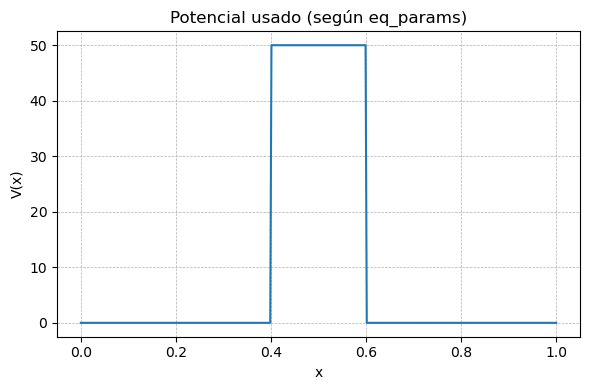

In [14]:
# Construir potencial a partir de eq_params
potential_fn = build_potential_fn(eq_params)

L = eq_params["L"]

x_test = torch.linspace(0., L, 400, device=DEVICE, dtype=torch.float32).reshape(-1,1)
t_zero = torch.zeros_like(x_test)

V_pde = potential_fn(t_zero, x_test).detach().cpu().numpy().flatten()
x_np  = x_test.detach().cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.plot(x_np, V_pde)
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potencial usado (según eq_params)")
plt.grid(True, ls="--", lw=0.5)
plt.tight_layout()
plt.show()


In [15]:
log_path = args["log_path"]
logger   = Logging(log_path)

if args["solver"] == "CV":
    model = CVPDESolver(args, logger, DEVICE)
    model.logger.print("Using CV Solver")
elif args["solver"] == "Classical":
    model = ClassicalSolver2(args, logger, DEVICE)
    model.logger.print("Using Classical Solver")
else:
    model = DVPDESolver(args, logger, DEVICE)
    model.logger.print("Using DV Solver")

DTYPE = torch.float32
torch.set_default_dtype(DTYPE)
torch.manual_seed(0)

total_params = sum(p.numel() for p in model.parameters())
model.logger.print(f"Total number of parameters: {total_params}")


INFO:src.utils.logger:checkpoint path: self.log_path='./results/models/checkpoints/schrodinger\\barrier\\2025-12-11_11-57-11-236270'
INFO:src.utils.logger:Using Classical Solver
INFO:src.utils.logger:Total number of parameters: 7902


In [16]:
wave_train.train(model, N_f=2000, N_b=400, N_0=400)


INFO:src.utils.logger:It: 1, Loss: 3.919e+00, Loss_res: 3.058e+00,  Loss_bcs: 6.495e-03, Loss_ut_ics: 8.543e-01, L^2_error: 1.003924e+00, lr: 1.000e-03, Time: 1.42e-01
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger\barrier\2025-12-11_11-57-11-236270\model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger\barrier\2025-12-11_11-57-11-236270\model_weights.pth
INFO:src.utils.logger:It: 200, Loss: 9.882e-01, Loss_res: 3.464e-03,  Loss_bcs: 8.965e-06, Loss_ut_ics: 9.847e-01, L^2_error: 9.985380e-01, lr: 1.000e-03, Time: 1.03e+01
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger\barrier\2025-12-11_11-57-11-236270\model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger\barrier\2025-12-11_11-57-11-236270\model_weights.pth
INFO:src.utils.logger:It: 400, Loss: 1.016e+00, Loss_res: 3.696e-03,  Loss_bcs: 1.207e-05, Loss_ut_ics: 1.012e+00, L^2_error: 9.98

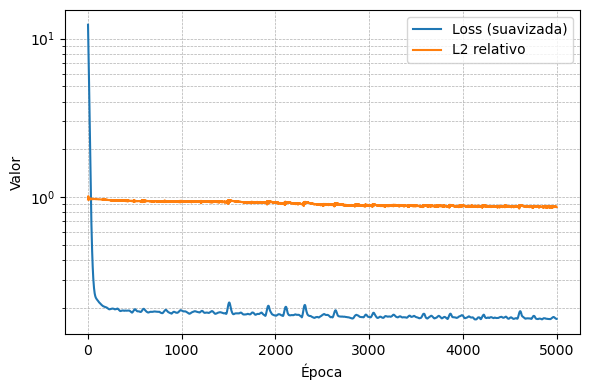

In [6]:
import numpy as np

epochs_arr = np.arange(1, len(model.loss_history) + 1)

loss_smooth = smooth_loss(np.array(model.loss_history))
l2_array    = np.array(model.l2_rel_history)

plt.figure(figsize=(6,4))
plt.plot(epochs_arr, loss_smooth, label="Loss (suavizada)")
plt.plot(epochs_arr, l2_array, label="L2 relativo")
plt.yscale("log")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

file_path = os.path.join(model.log_path, "LossVsError.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.close("all")


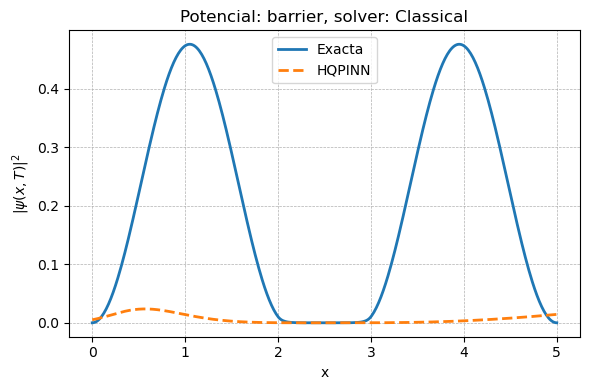

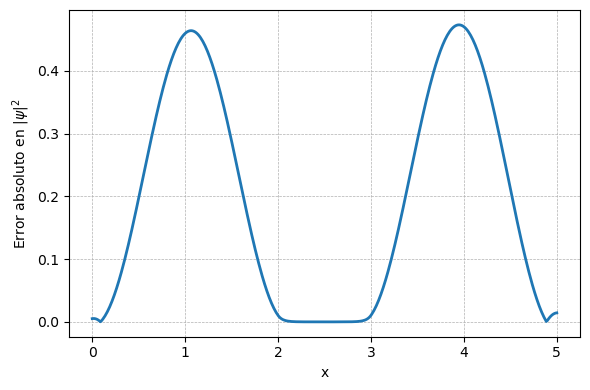

In [7]:
model.eval()
with torch.no_grad():
    Nx = 400
    if example == "ho":
        x_eval = torch.linspace(-L, L, Nx, device=DEVICE, dtype=DTYPE).reshape(-1,1)
    else:
        x_eval = torch.linspace(0.0, L, Nx, device=DEVICE, dtype=DTYPE).reshape(-1,1)

    t_eval = torch.full_like(x_eval, T)

    # Predicción del modelo
    psi_pred = model(torch.cat((t_eval, x_eval), dim=1))
    psi_r_pred = psi_pred[:, 0:1]
    psi_i_pred = psi_pred[:, 1:2]
    prob_pred  = (psi_r_pred**2 + psi_i_pred**2).cpu().numpy().flatten()

    # Solución exacta
    exact_kwargs = dict(L=L, mass=mass, hbar=hbar, omega=eq_params.get("omega", 1.0), example=example)
    if example == "barrier":
        exact_kwargs.update(
            V0=eq_params.get("V0", 50.0),
            barrier_width=eq_params.get("barrier_width", L/5.0),
            num_grid=eq_params.get("num_grid", 400),
        )

    psi_r_exact, psi_i_exact, _ = exact_eigenstate(
        eq_params["n_level"], t_eval, x_eval, **exact_kwargs
    )
    prob_exact = (psi_r_exact**2 + psi_i_exact**2).cpu().numpy().flatten()

x_np = x_eval.cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.plot(x_np, prob_exact, label="Exacta", lw=2)
plt.plot(x_np, prob_pred, "--", label="HQPINN", lw=2)
plt.xlabel("x")
plt.ylabel(r"$|\psi(x,T)|^2$")
plt.title(f"Potencial: {potential_type}, solver: {solver_type}")
plt.grid(True, ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Error puntual
plt.figure(figsize=(6,4))
plt.plot(x_np, np.abs(prob_pred - prob_exact), lw=2)
plt.xlabel("x")
plt.ylabel("Error absoluto en $|\psi|^2$")
plt.grid(True, ls="--", lw=0.5)
plt.tight_layout()
plt.show()
